In [1]:
!pip install qiskit qiskit-aer matplotlib numpy scipy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT
from scipy.integrate import solve_ivp
import time
from typing import Tuple, List, Dict

In [3]:
class QuantumPDEConfig:

    def __init__(self, test_case=1):
        self.test_case = test_case


        #TEST CASE 1: Traveling waves
        if test_case == 1:
            # Case I: Traveling Waves
            self.L = 6.0
            self.nx = 32  # Reduced for feasibility
            self.nu = 1.0
            self.T = 1.0 # Reduced time
            self.dt = 0.01
            self.num_steps = 12  # Fewer steps
            self.wave_velocity = 4
            self.courant_number = 0.04
            self.boundary_type = "zero"

            def initial_condition(x):
                return 2.0 * (1.0 - np.tanh(x - self.L/2))

        #TEST CASE 2: Shock Formation
        elif test_case == 2:
            self.L = 1.0
            self.nx = 32  # Small but tractable
            self.nu = 0.001  # Increased viscosity for stability
            self.T = 0.3  # Short time
            self.dt = 0.005
            self.num_steps = 12 # Very few steps
            self.wave_velocity = 2
            self.courant_number = 0.1
            self.boundary_type = "floating"

            def initial_condition(x):
                return 1.0 + 2.0 * np.pi * np.sin(np.pi * x / self.L)

        # Quantum algorithm parameters
        self.m1 = 6   # Precision bits (balance accuracy vs circuit depth)
        self.m2 = int(np.ceil(np.log2(self.nx)))  # Grid size bits
        self.m3 =  1  # Truncation bits (reduced for speed)
        self.shots = 1054 # Reasonable shot count
        self.M_samples = 2  # Fewer samples for faster execution

        # Error tolerances
        self.epsilon_1 = 2 * np.pi / (2**self.m1)
        self.epsilon_d = 1 / self.nx
        self.epsilon_gamma = 1 / (2**self.m3)

        print(f"\n{'='*60}")
        print(f"FIXED Quantum PDE Configuration - Test Case {test_case}")
        print(f"{'='*60}")
        print(f"Domain: [0, {self.L}], Grid points: {self.nx}")
        print(f"Viscosity ν: {self.nu}, Time steps: {self.num_steps}")
        print(f"Quantum Parameters:")
        print(f"  m₁ (precision): {self.m1}, ε₁ = {self.epsilon_1:.6f}")
        print(f"  m₂ (grid): {self.m2}, ε_d = {self.epsilon_d:.6f}")
        print(f"  m₃ (truncation): {self.m3}, ε_γ = {self.epsilon_gamma:.6f}")
        print(f"{'='*60}\n")

config = QuantumPDEConfig(test_case=1)


FIXED Quantum PDE Configuration - Test Case 1
Domain: [0, 6.0], Grid points: 32
Viscosity ν: 1.0, Time steps: 12
Quantum Parameters:
  m₁ (precision): 6, ε₁ = 0.098175
  m₂ (grid): 5, ε_d = 0.031250
  m₃ (truncation): 4, ε_γ = 0.062500



In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==============================================================
# Burgers RHS
# ==============================================================
def burgers_rhs(t, u, nu, dx, nx):
    dudt = np.zeros_like(u)
    for i in range(1, nx-1):
        # Upwind scheme for nonlinear convection
        if u[i] >= 0:
            dudx = (u[i] - u[i-1]) / dx
        else:
            dudx = (u[i+1] - u[i]) / dx
        # Central difference for viscous term
        d2udx2 = (u[i+1] - 2*u[i] + u[i-1]) / dx**2
        dudt[i] = -u[i] * dudx + nu * d2udx2
    # Boundary conditions
    dudt[0] = 0
    dudt[-1] = 0
    return dudt

In [5]:
def solve_classical_burgers(config):
    x_grid = np.linspace(0, config.L, config.nx)
    u0 = config.initial_condition(x_grid)
    if config.boundary_type == "zero":
        u0[0] = 0.0
        u0[-1] = 0.0
    sol = solve_ivp(
        lambda t, u: burgers_rhs(t, u, config.nu, config.dx, config.nx),
        (0, config.T),
        u0,
        method='RK45',
        rtol=1e-6,
        atol=1e-8,
        dense_output=True
    )
    return sol, x_grid, u0


In [6]:
# Amplitude Preparation
def prepare_amplitude_state(integrand_values):
    """
     Oracle O
    """
    M2 = len(integrand_values)
    m2 = int(np.ceil(np.log2(M2)))

    # Normalize integrand to [0, 1]
    g_min = np.min(integrand_values)
    g_max = np.max(integrand_values)
    g_range = g_max - g_min

    if g_range < 1e-10:
        g_normalized = np.ones_like(integrand_values) * 0.5
        scaling = (g_min, 1.0)
    else:
        g_normalized = (integrand_values - g_min) / g_range
        scaling = (g_min, g_range)

    g_normalized = np.clip(g_normalized, 0, 1)

    # Create quantum registers
    qr_index = QuantumRegister(m2, 'index')
    qr_amp = QuantumRegister(1, 'amplitude')
    qc = QuantumCircuit(qr_index, qr_amp)

    # Prepare uniform superposition over indices
    qc.h(qr_index)

    # Encode amplitudes according to paper Eq. (28)
    for j in range(min(M2, 2**m2)):
        if j < len(g_normalized):
            # Paper Eq. (28): encode sin²(πg(τⱼ))
            g_scaled = g_normalized[j]


            angle = 2 * np.arcsin(np.sqrt(g_scaled))

            # Create control pattern for index j
            control_string = format(j, f'0{m2}b')

            # Apply X gates to set up control state
            for k, bit in enumerate(control_string):
                if bit == '0':
                    qc.x(qr_index[k])

            # Apply multi-controlled RY rotation
            qc.mcry(angle, qr_index, qr_amp[0])

            # Undo X gates to reset control qubits
            for k, bit in enumerate(control_string):
                if bit == '0':
                    qc.x(qr_index[k])

    return qc, g_normalized, scaling


In [7]:
from qiskit import QuantumCircuit, QuantumRegister

def create_grover_operator(state_prep_circuit, m2, m3):
    """
     Oracle Q
    Q = A · U₀ · A⁻¹ · U_{n₀}
    """
    qr_index = QuantumRegister(m2, 'index')
    qr_amp = QuantumRegister(m3, 'amplitude')

    qc = QuantumCircuit(qr_index, qr_amp)

    # Step 1: U_{n0} - reflection about amplitude qubit |0>
    qc.z(qr_amp)

    # Step 2: A^-1 - inverse of state preparation
    qc.compose(state_prep_circuit.inverse(), inplace=True)

    # Step 3: U_0 - reflection about |0...0> state
    qc.x(qr_index)
    qc.x(qr_amp)

    all_qubits = list(qr_index) + [qr_amp[0]]

    if len(all_qubits) > 1:
        # H-MCX-H trick: multi-controlled Z
        qc.h(all_qubits[-1])
        qc.mcx(all_qubits[:-1], all_qubits[-1])
        qc.h(all_qubits[-1])
    else:
        qc.z(all_qubits[0])

    qc.x(qr_index)
    qc.x(qr_amp)

    # Step 4: A - restore state preparation
    qc.compose(state_prep_circuit, inplace=True)

    return qc




In [8]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import Aer

def quantum_amplitude_estimation(integrand_values, m1, shots=1048):
    M2 = len(integrand_values)
    m2 = int(np.ceil(np.log2(M2)))
    M1 = 2**m1

    # Create state preparation circuit
    state_prep, g_norm, scaling = prepare_amplitude_state(integrand_values)
    num_state_qubits = state_prep.num_qubits

    # Grover operator
    grover = create_grover_operator(state_prep, m2)

    # QPE circuit
    qr_phase = QuantumRegister(m1, 'phase')
    qr_state = QuantumRegister(num_state_qubits, 'state')
    cr = ClassicalRegister(m1, 'measurement')
    qpe_circuit = QuantumCircuit(qr_phase, qr_state, cr)

    # Initialize state register |ψ>
    qpe_circuit.compose(state_prep, qubits=qr_state, inplace=True)

    # Apply Hadamard to phase register
    qpe_circuit.h(qr_phase)

    # Apply controlled-Q^(2^j) correctly
    for j in range(m1):
        controlled_grover = grover.control(1)
        qpe_circuit.compose(controlled_grover.power(2**j),
                            qubits=[qr_phase[m1 - 1 - j]] + list(qr_state),
                            inplace=True)

    # Inverse QFT
    qpe_circuit.append(QFT(m1, inverse=True).to_gate(), qr_phase)

    # Measure phase register
    qpe_circuit.measure(qr_phase, cr)

    # Get circuit depth 
    
    circuit_depth = qpe_circuit.depth()
    total_qubits = qpe_circuit.num_qubits  # This includes all registers

    # Execute circuit
    backend = Aer.get_backend('aer_simulator')
    transpiled = transpile(qpe_circuit, backend, optimization_level=3)
    job = backend.run(transpiled, shots=shots)
    result = job.result()
    counts = result.get_counts()

    # Extract phase estimate (weighted average)
    phase_sum = 0
    total_counts = 0
    for bitstring, count in counts.items():
        phase_int = int(bitstring, 2)
        phase_sum += (phase_int / M1) * count
        total_counts += count
    phase = phase_sum / total_counts

    # Convert phase to amplitude estimate
    theta_a = phase * np.pi
    a_estimate = np.sin(theta_a)**2

    # Scale back using stored normalization
    g_min, g_range = scaling
    g_estimate_normalized = np.arcsin(np.sqrt(a_estimate)) / np.pi
    g_estimate_actual = g_estimate_normalized * g_range + g_min

    return g_estimate_actual, phase, counts, (circuit_depth, total_qubits)

In [9]:
def quantum_integrate(u_current, t_current, dt, config):
    nx = config.nx
    M = config.M_samples
    tau_samples = np.linspace(t_current, t_current + dt, M)
    f_current = burgers_rhs(t_current, u_current, config.nu, config.dx, nx)
    integrand_values = np.zeros((M, nx))
    for k, tau in enumerate(tau_samples):
        theta = (tau - t_current) / dt if dt > 0 else 0
        u_tau = u_current + theta * dt * f_current
        f_tau = burgers_rhs(tau, u_tau, config.nu, config.dx, nx)
        integrand_values[k, :] = f_tau
    u_integral = np.zeros(nx)
    max_depth = 0
    max_qubits = 0
    for i in range(nx):
        g_values = integrand_values[:, i]
        g_min, g_max = g_values.min(), g_values.max()
        g_range = g_max - g_min
        if g_range < 1e-12:
            u_integral[i] = dt * g_min
            continue
        g_norm = (g_values - g_min) / g_range
        g_norm = np.clip(g_norm, 0.0, 1.0)
        try:
            mean_norm, _, _, metrics = quantum_amplitude_estimation(
                g_norm, config.m1, config.m3, config.shots
            )
        except Exception as e:
            print(f"Warning: QAEA failed at index {i}: {e}")
            mean_norm = np.mean(g_norm)
            metrics = (0, 0)
        mean_val = mean_norm * g_range + g_min
        u_integral[i] = dt * mean_val
        max_depth = max(max_depth, metrics[0])
        max_qubits = max(max_qubits, metrics[1])
    return u_integral, (max_depth, max_qubits)


In [10]:
def quantum_integrate_richardson(u_current, t_current, dt, config):
    I_coarse, metrics_coarse = quantum_integrate(u_current, t_current, dt, config)
    I_fine1, metrics_fine1 = quantum_integrate(u_current, t_current, dt/2, config)
    u_mid = u_current + I_fine1
    I_fine2, metrics_fine2 = quantum_integrate(u_mid, t_current + dt/2, dt/2, config)
    I_fine = I_fine1 + I_fine2
    I_improved = (4 * I_fine - I_coarse) / 3
    combined_depth = max(metrics_coarse[0], metrics_fine1[0], metrics_fine2[0])
    combined_qubits = max(metrics_coarse[1], metrics_fine1[1], metrics_fine2[1])
    return I_improved, (combined_depth, combined_qubits)

def quantum_integrate_adaptive(u_current, t_current, dt, config, use_richardson=False):
    if use_richardson and dt > 1e-9:
        return quantum_integrate_richardson(u_current, t_current, dt, config)
    else:
        return quantum_integrate(u_current, t_current, dt, config)


EXECUTING QUANTUM BURGERS SOLVER

Running classical solver...
Classical solver completed in 0.02 seconds

Starting quantum Burgers solver


/var/folders/yv/m7vtdt5s2456118y_vyytxnr0000gn/T/ipykernel_42882/3388598018.py:37: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qpe_circuit.append(QFT(m1, inverse=True).to_gate(), qr_phase)
/var/folders/yv/m7vtdt5s2456118y_vyytxnr0000gn/T/ipykernel_42882/3388598018.py:37: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qpe_circuit.append(QFT(m1, inverse=True).to_gate(), qr_phase)


Timestep 1/12 completed.  Max qubits: 8
Timestep 2/12 completed.  Max qubits: 8
Timestep 3/12 completed.  Max qubits: 8
Timestep 4/12 completed.  Max qubits: 8
Timestep 5/12 completed.  Max qubits: 8
Timestep 6/12 completed.  Max qubits: 8
Timestep 7/12 completed.  Max qubits: 8
Timestep 8/12 completed.  Max qubits: 8
Timestep 9/12 completed.  Max qubits: 8
Timestep 10/12 completed.  Max qubits: 8
Timestep 11/12 completed.  Max qubits: 8
Timestep 12/12 completed.  Max qubits: 8

Quantum simulation completed
Number of qubits: 8
Circuit Depth: 74
Quantum solver completed in 442.29 seconds

Quantum vs Classical Comparison:
Maximum absolute error: 0.025117
Mean absolute error: 0.000505
Maximum relative error: 0.92%
Mean relative error: 0.02%


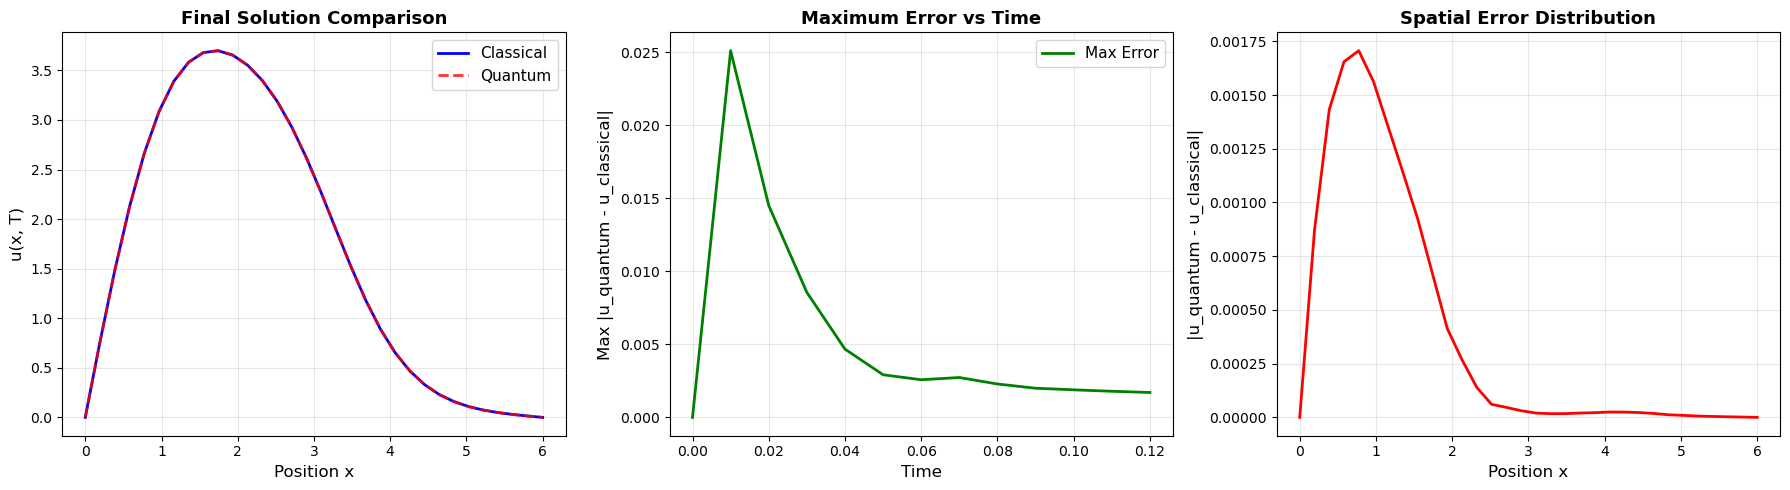

In [11]:
def quantum_burgers_solver(config, use_richardson=True):
    nx = config.nx
    nt = config.num_steps
    dt = config.dt
    u = config.initial_condition(np.linspace(0, config.L, config.nx)).copy() # Initialize u from config's initial condition
    if config.boundary_type == "zero":
        u[0] = 0.0
        u[-1] = 0.0
    u_history = np.zeros((nt+1, nx))
    u_history[0, :] = u
    metrics_history = []
    for n in range(1, nt+1):
        t_current = (n-1) * dt
        du, metrics = quantum_integrate_adaptive(u, t_current, dt, config, use_richardson=use_richardson)
        u = u + du
        u_history[n, :] = u
        metrics_history.append(metrics)
        print(f"Timestep {n}/{nt} completed.  Max qubits: {metrics[1]}")
    return u_history, metrics_history

def analyze_results_simple(quantum_sol, classical_sol, config, x_grid_classical):
    t_quantum = np.arange(len(quantum_sol)) * config.dt
    if hasattr(classical_sol, "sol"):
        classical_interp = classical_sol.sol(t_quantum).T
    else:
        classical_interp = np.array(classical_sol)
        if classical_interp.ndim == 1:
            classical_interp = classical_interp[None, :]
    if classical_interp.shape != np.array(quantum_sol).shape:
        min_steps = min(len(quantum_sol), len(classical_interp))
        quantum_sol = np.array(quantum_sol[:min_steps])
        classical_interp = np.array(classical_interp[:min_steps])
        t_quantum = t_quantum[:min_steps]

    absolute_errors = np.abs(quantum_sol - classical_interp)
    relative_errors = absolute_errors / (np.abs(classical_interp) + 1e-10)

    max_abs_error = np.max(absolute_errors)
    mean_abs_error = np.mean(absolute_errors)
    max_rel_error = np.max(relative_errors)
    mean_rel_error = np.mean(relative_errors)

    print("\nQuantum vs Classical Comparison:")
    print(f"Maximum absolute error: {max_abs_error:.6f}")
    print(f"Mean absolute error: {mean_abs_error:.6f}")
    print(f"Maximum relative error: {max_rel_error*100:.2f}%")
    print(f"Mean relative error: {mean_rel_error*100:.2f}%")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Final Solution Comparison
    ax = axes[0]
    ax.plot(x_grid_classical, classical_interp[-1], 'b-', label='Classical', linewidth=2)
    ax.plot(x_grid_classical, quantum_sol[-1], 'r--', label='Quantum', linewidth=2, alpha=0.8)
    ax.set_xlabel('Position x', fontsize=12)
    ax.set_ylabel('u(x, T)', fontsize=12)
    ax.set_title('Final Solution Comparison', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    # Plot 2: Maximum Error vs Time
    ax = axes[1]
    max_errors_time = np.max(absolute_errors, axis=1)
    ax.plot(t_quantum, max_errors_time, 'g-', linewidth=2, label='Max Error')
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Max |u_quantum - u_classical|', fontsize=12)
    ax.set_title('Maximum Error vs Time', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    # Plot 3: Spatial Error Distribution
    ax = axes[2]
    ax.plot(x_grid_classical, absolute_errors[-1], 'r-', linewidth=2)
    ax.set_xlabel('Position x', fontsize=12)
    ax.set_ylabel('|u_quantum - u_classical|', fontsize=12)
    ax.set_title('Spatial Error Distribution', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('quantum_burgers_simplified_results.png', dpi=300, bbox_inches='tight')
    plt.show(block=True)

    return {
        'max_abs_error': max_abs_error,
        'mean_abs_error': mean_abs_error,
        'max_rel_error': max_rel_error,
        'mean_rel_error': mean_rel_error
    }

# ==============================================================
# Main execution
# ==============================================================
print("\n" + "="*60)
print("EXECUTING QUANTUM BURGERS SOLVER")
print("="*60)

# Classical solver
print("\nRunning classical solver...")
start_time = time.time()
classical_sol, x_grid_classical, u0_classical = solve_classical_burgers(config)
classical_time = time.time() - start_time
print(f"Classical solver completed in {classical_time:.2f} seconds")

# Quantum solver (vectorized, full state)
print("\nStarting quantum Burgers solver")
start_time = time.time()
quantum_solution, metrics_history = quantum_burgers_solver(config, use_richardson=True)
quantum_time = time.time() - start_time
print("\nQuantum simulation completed")
print(f"Number of qubits: {metrics_history[-1][1]}")
print(f"Circuit Depth: {metrics_history[-1][0]}")
print(f"Quantum solver completed in {quantum_time:.2f} seconds")

# Analysis
results = analyze_results_simple(quantum_solution, classical_sol, config, x_grid_classical)